In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore", "use_inf_as_na")

`sns.load_dataset()` loads a DataFrame from the *Seaborn* library

In [2]:
iris = sns.load_dataset("iris")
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


# Matplotlib histogram

## basic histogram for one column. Change figure size with `figsize`

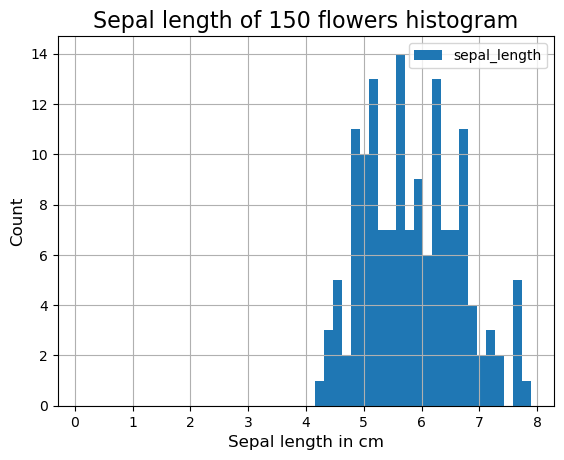

In [12]:
ax = iris.plot.hist(column=["sepal_length"], bins=50, grid=True)
ax.set_title("Sepal length of 150 flowers histogram", fontsize=16)
ax.set_xlabel("Sepal length in cm", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
plt.show()

## Advanced histogram with Matplotlib

- Create several histogram and graph them into one plot

In [9]:
iris.groupby("species")

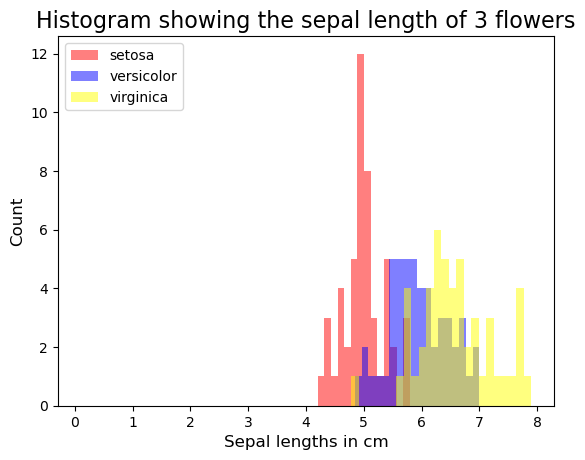

In [13]:
fig, ax = plt.subplots()
colours = {"setosa": "Red",
           "versicolor": "Blue",
           "virginica": "Yellow",
          }
for Species, data in iris.groupby("species"):
    data.plot(kind="hist", column="sepal_length", bins=50, alpha=0.5, color=colours[Species], ax=ax)
ax.set_xlabel("Sepal lengths in cm", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.legend(colours.keys(), loc="upper left")
fig.suptitle("")
ax.set_title("Histogram showing the sepal length of 3 flowers", fontsize=16)
plt.show()

### Code explanation

Matplotlib’s `plt.subplots()` is a common way to create a plot: it returns two objects, typically called `fig` and `ax`.<br>
Here `fig` is a **Figure** object (the overall container or “canvas” for the plot) and `ax` is an **Axes** object (the actual plotting area with its own coordinate system).<br>
Using this convention is helpful because you often want to manipulate both the figure-level settings (like saving to file or a super-title) and the axes-level settings (labels, titles). For example:
- `fig`: a `matplotlib.figure.Figure` instance. It represents the entire figure (the window or page).<br> You use `fig` for figure-wide actions, such as `fig.savefig(...)` or `fig.suptitle(...)` (an overall title for the whole figure).
- `ax` – a `matplotlib.axes.Axes` instance. It represents one set of axes (the plot area) inside the figure.<br> All plotting methods (like `ax.plot()`, `ax.scatter()`) and axes labels or ticks belong to this object. You use ax to set titles and axis labels for that subplot.

#### How `plt.subplots()` works

The function `plt.subplots()` is a convenient wrapper that creates a new Figure and one or more Axes in one call.<br> By default, calling `fig, ax = plt.subplots()` makes one figure (`fig` containing a single subplot (`ax`). Internally, it is equivalent to doing `fig = plt.figure()` and then `ax = fig.add_subplot(1,1,1)`, but is much more concise.<br> You can customize the number and arrangement of subplots by passing arguments, for example `plt.subplots(nrows=2, ncols=2)` to make a 2×2 grid. In that case, `ax` will be an array of Axes objects (one for each subplot).<br> The `subplots()` function has options like `sharex`, `sharey`, `squeeze`, etc., to control shared axes and output shape, but in the simplest case it just gives you a figure and axes for plotting. After calling `plt.subplots()`, you have a fresh plotting area (`ax`) on which you can draw data (lines, points, etc.) and a Figure (`fig`) that can hold one or more such axes.

#### Iterating over `iris.groupby("species")`

In the loop `for species, data in iris.groupby("species")`, the `iris.groupby("species")` call returns a pandas `DataFrameGroupBy` **object**.<br> Iterating over a `DataFrameGroupBy` yields **one tuple per group**: each iteration gives (group_name, group_dataframe). In this case:
- `species` is the name/key of the group (the unique value of the *species* column, e.g. "setosa", "versicolor", "virginica").
- `data` is a new DataFrame containing **only** the rows of iris where *species* has that value.

#### The `plt.show()` function and displaying the plot

The call `plt.show()` tells Matplotlib to display the figure(s) you have created. By default it displays all open figures (without needing you to specify which one). In most scripts or non-interactive use, the figure won’t appear on screen until you call `plt.show()`. It “knows” which plot to show because it simply renders all figures that have been created (and not yet closed).<br> 
You don’t pass it any figure name because it’s a global command. In a typical script or terminal session, calling `plt.show()` is required to pop up the window with your plot. (*In interactive IPython or Jupyter environments, plots often auto-display without needing `show()`, which is why one sometimes sees code without it.*)<br>
In summary, use `plt.show()` once at the end to display your figure(s) – it does not take arguments and will show any figures you have built.

# Seaborn

## Basic Seaborn histogram

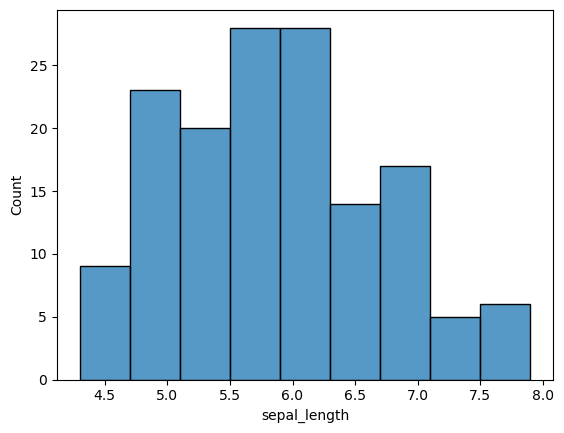

In [14]:
sns.histplot(data=iris, x="sepal_length")
plt.show()

***

- add a determined number of bins

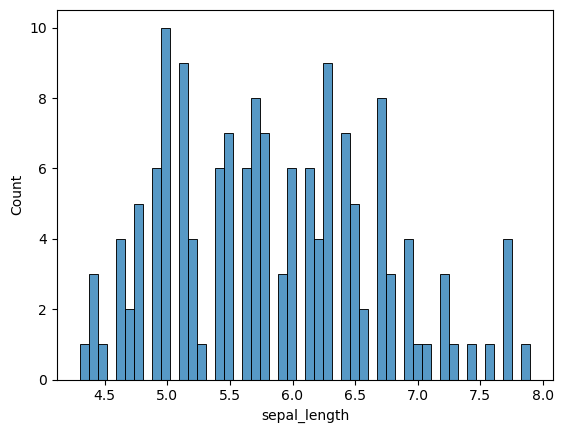

In [15]:
sns.histplot(data=iris, x="sepal_length", bins=50)
plt.show()

## Advanced Seaborn histogram

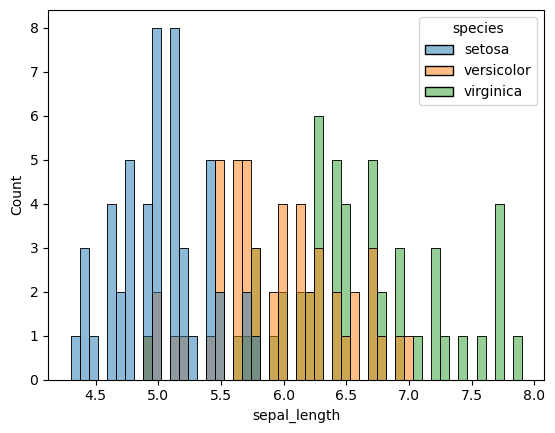

In [16]:
sns.histplot(data=iris, x="sepal_length", bins=50, hue="species")
plt.show()

## Special Seaborn histograms

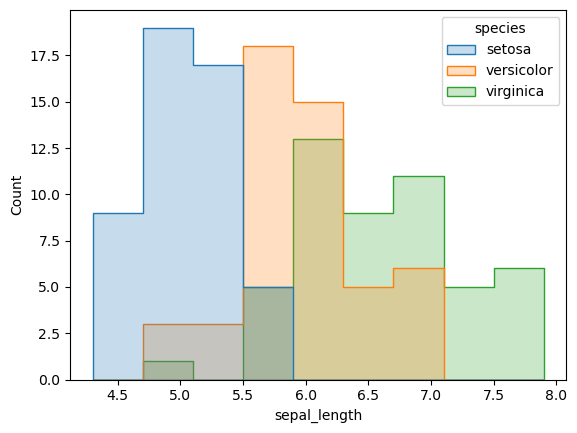

In [17]:
sns.histplot(data=iris, x="sepal_length", hue="species", element="step")
plt.show()

***

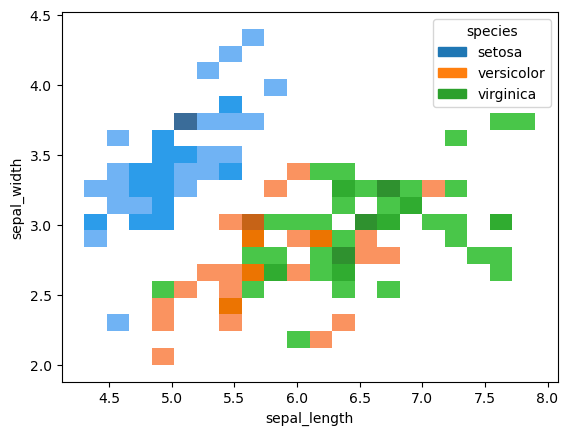

In [18]:
sns.histplot(data=iris, x="sepal_length", y="sepal_width", bins=20, hue="species")
plt.show()

***

- 4 histograms in 1 graph - `JointGrid`

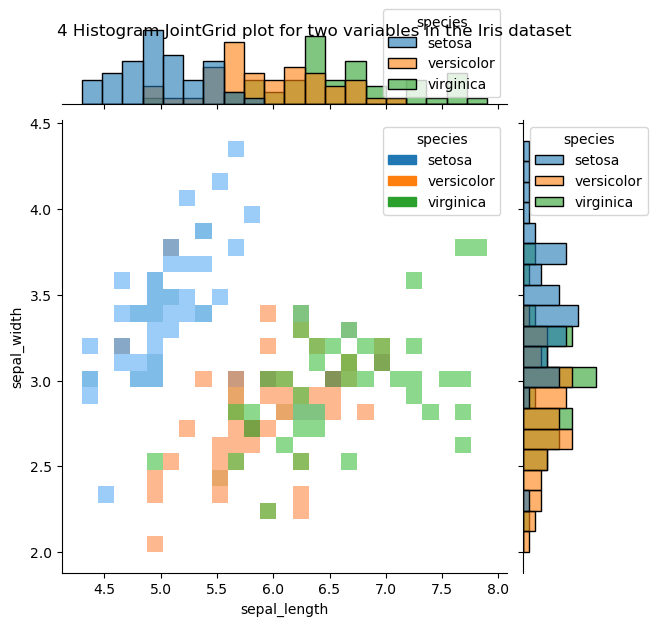

In [23]:
graph = sns.JointGrid()
sns.histplot(data=iris, x="sepal_length", y="sepal_width", bins=25, hue="species", alpha=0.6, ax=graph.ax_joint)
sns.histplot(data=iris, x="sepal_length", bins=20, hue="species", alpha=0.6, ax=graph.ax_marg_x)
sns.histplot(data=iris, y="sepal_width", bins=20, hue="species", alpha=0.6, ax=graph.ax_marg_y)
graph.fig.suptitle("4 Histogram JointGrid plot for two variables in the Iris dataset") 
plt.show()